# Hành chính — cơ quan nhà nước, công an, toà án, bưu điện

Nối tiếp `eda_benhvien.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_benhvien.parquet`.

## Vì sao lớp này chạy TRƯỚC lớp văn phòng (đảo so với danh sách gốc)

Danh sách ban đầu xếp *văn phòng* trước *hành chính*. Số đo bác thứ tự đó:
**`office=government` chiếm ≈ 42% mọi `office=*` còn lại trong bộ** (1.353/3.187 ở lần
đo đầu — số hiện hành in ở cell chân dung, đừng tin số viết tay). Lớp văn
phòng chạy trước sẽ nuốt trọn khối cơ quan nhà nước, và lớp hành chính chỉ còn nhặt phần
thừa. Đảo lại thì mỗi lớp lấy đúng phần của mình. Quyết định này có số chống lưng, ghi ở
đây để đảo ngược được.

## Lớp DUY NHẤT của chuỗi có thước NGOÀI thật

Sáu lớp trước không lớp nào có gold set. Lớp này có, và nó đến từ một chỗ không ai ngờ:
**bộ máy hành chính Việt Nam có số lượng CỐ ĐỊNH và BIẾT TRƯỚC.** Mỗi xã/phường có đúng
một UBND. Kho `store/admin/communes.parquet` (niên bản VNSDI, hiệu lực 16/6/2025) cho biết
7 tỉnh này có bao nhiêu xã — tức mẫu số thật của phép đo recall.

Đó là điều không lớp nào trước làm được: ta không biết có bao nhiêu quán cà phê ở Hà Nội,
nhưng ta biết chính xác có bao nhiêu UBND phường.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "hanhchinh"
LOP_TRUOC = "benhvien"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "amenity",
    "office",
    "government",
    "military",
    "boundary",
    "building",
    "landuse",
    "shop",
    "leisure",
    "tourism",
    "healthcare",
    "historic",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "craft",
    "place",
    "religion",
    "emergency",
]:
    poi[k] = tag(k)
poi["operator"] = td.map(lambda t: t.get("operator"))
poi["operator_type"] = td.map(lambda t: t.get("operator:type"))
poi["admin_level"] = td.map(lambda t: t.get("admin_level"))

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)

bộ vào: 147,947 dòng | polygon 32% | có tên 43%


## Chân dung hình thái

In [2]:
_uv = poi[
    poi["office"].isin(["government", "administrative", "diplomatic", "political_party"])
    | poi["government"].notna()
    | poi["amenity"].isin(
        [
            "townhall",
            "courthouse",
            "police",
            "fire_station",
            "post_office",
            "prison",
            "public_building",
            "embassy",
        ]
    )
    | poi["military"].notna()
    | name_norm.str.contains(
        r"\bubnd\b|uy ban nhan dan|\bhdnd\b|\bcong an\b|toa an|vien kiem sat", na=False
    )
]
print(
    f"ứng viên thô: {len(_uv):,} | polygon {_uv['is_area'].mean():.0%}"
    f" | có tên {_uv['name'].notna().mean():.0%} ← cao nhất mọi lớp"
    f" | n_tags trung vị {_uv['n_tags'].median():.0f}"
)

print("\n── các họ tag ứng viên ──")
for k in ["office", "government", "amenity", "military", "boundary", "operator_type"]:
    v = poi[k].value_counts()
    print(f"  {k:14s} {v.sum():6,} → {v.head(8).to_dict()}")

print("\n── BẪY `operator`: ở VN gần như MỌI thứ đều do một cơ quan nhà nước đứng tên ──")
op = poi["operator"].fillna("").map(strip_accents)
nha_nuoc = op.str.contains(r"\bubnd\b|uy ban|\bso \b|\bcuc \b|nha nuoc|chinh phu|bo \w", na=False)
print(f"  `operator` nhắc tới cơ quan nhà nước: {int(nha_nuoc.sum()):,} dòng")
print(
    f"  trong đó THỰC SỰ là cơ quan hành chính (có office/government/amenity tương ứng):"
    f" {int((nha_nuoc & (poi['office'].eq('government') | poi['government'].notna() | poi['amenity'].isin(['townhall', 'courthouse']))).sum()):,}"
)
print(
    "  mẫu dòng có operator nhà nước mà KHÔNG phải cơ quan:",
    poi.loc[nha_nuoc & poi["office"].isna() & poi["government"].isna(), "name"]
    .dropna()
    .head(5)
    .tolist(),
)
print(
    "  → `operator` là CHỦ SỞ HỮU, không phải LOẠI. Hai lớp trước đã trả giá cho bài học"
    " này; ở đây nó nặng nhất, nên `operator` KHÔNG được dùng làm nhánh tuyển."
)

ứng viên thô: 4,071 | polygon 66% | có tên 92% ← cao nhất mọi lớp | n_tags trung vị 4

── các họ tag ứng viên ──
  office          3,215 → {'government': 1384, 'company': 817, 'yes': 220, 'diplomatic': 123, 'telecommunication': 69, 'political_party': 69, 'estate_agent': 50, 'newspaper': 44}
  government        740 → {'administrative': 279, 'tax': 85, 'ministry': 72, 'yes': 55, 'social_security': 32, 'prosecutor': 32, 'treasury': 30, 'customs': 24}
  amenity        31,977 → {'restaurant': 7024, 'cafe': 5760, 'atm': 2667, 'bank': 1776, 'fuel': 1729, 'parking': 1476, 'pharmacy': 1311, 'fast_food': 1003}
  military          183 → {'office': 34, 'base': 33, 'barracks': 29, 'checkpoint': 25, 'bunker': 23, 'range': 21, 'training_area': 8, 'airfield': 5}
  boundary          213 → {'administrative': 209, 'special_economic_zone': 2, 'historic': 1, 'postal_code': 1}
  operator_type      61 → {'private': 13, 'public': 12, 'university': 11, 'government': 11, 'business': 6, 'military': 3, 'museum': 

### Chọn trục

1. **CẤP HÀNH CHÍNH — một hệ từ vựng ĐÓNG và CÓ THỨ TỰ.** Tiếng Việt hành chính không mơ
   hồ: *bộ / tổng cục / cục* là trung ương — **cục là cơ quan THUỘC BỘ**, dù trụ sở đóng tại
   địa phương (ngoại lệ kiểu cũ: *cục thuế / cục hải quan <tỉnh>* là cấp tỉnh; sửa theo
   `review_hanhchinh.md`, NỢ 3) — *sở* là cấp tỉnh, *phòng / chi cục / UBND quận
   – huyện* là cấp huyện, *UBND phường – xã* là cấp xã. Đây là hệ danh pháp chặt nhất mà
   chuỗi gặp — chặt hơn cả cấp học, vì nó do luật quy định chứ không do thói quen đặt tên.
2. **NGÀNH** — chính quyền chung · công an · toà án–kiểm sát · thuế–kho bạc · bưu điện ·
   đảng–đoàn thể · quân đội. Vuông góc với cấp.
3. **ĐỐI CHỨNG VỚI SỐ ĐƠN VỊ HÀNH CHÍNH THẬT** — trục kiểm định, và là thước NGOÀI duy nhất
   của cả chuỗi.

**Trục bị loại có lý do:** `operator` (xem chân dung — chủ sở hữu ≠ loại); *diện tích* (trụ
sở UBND xã và UBND tỉnh không chênh nhau theo cấp một cách ổn định); *sức hút* (không có
khách phương xa).

## Bước 1 — filter MỎNG, ưu tiên recall

In [3]:
HC_TAG = (
    poi["office"].isin(["government", "administrative", "diplomatic", "political_party", "quango"])
    | poi["government"].notna()
    | poi["amenity"].isin(
        [
            "townhall",
            "courthouse",
            "police",
            "fire_station",
            "post_office",
            "prison",
            "public_building",
            "embassy",
            "customs",
        ]
    )
    | poi["military"].notna()
    | poi["landuse"].eq("military")
    | poi["building"].isin(["government", "civic", "public"])
    | poi["operator_type"].isin(["government", "public/government", "military"])
)
# Từ vựng hành chính ĐỊNH DANH — mỗi cụm tự nó đã đủ chỉ ra một cơ quan.
HC_RX = (
    r"\bubnd\b|uy ban nhan dan|uy ban nd|\bhdnd\b|hoi dong nhan dan"
    r"|\bcong an\b|\bdon cong an\b|canh sat|\bpccc\b|phong chay|\bcsgt\b"
    r"|toa an|vien kiem sat|\bvksnd\b|thi hanh an|trai giam|nha tam giu"
    r"|kho bac|\bchi cuc thue\b|\bcuc thue\b|hai quan|bao hiem xa hoi|\bbhxh\b"
    r"|buu dien|\bbuu cuc\b"
    r"|dang uy|quan uy|huyen uy|tinh uy|thanh uy|xa uy|thi uy|ban tuyen giao|ban dan van"
    r"|hoi (?:phu nu|nong dan|cuu chien binh)|doan thanh nien|mat tran to quoc|\bmttq\b"
    r"|ban chi huy quan su|\bbchqs\b|don bien phong|bo tu lenh|quan khu|su doan|trung doan"
    # Lưới rộng quét bộ CÒN LẠI (Bước 7) bắt được 7 dòng cơ quan thật lọt ra ngoài; đây là
    # 4 lỗ của từ vựng: phiên hiệu quân đội ngoài `su doan|trung doan`, cơ quan ngoại giao
    # không khai `office=diplomatic` ("Đại sứ quán Hoa Kỳ"), "Khu hành chính <phường>", và
    # ngành khí tượng thuỷ văn.
    r"|doanh trai|quan doi nhan dan|lu doan|tieu doan|binh doan|binh chung|hai doan"
    r"|dai su quan|lanh su quan|tong lanh su|\bembassy\b|\bconsulate\b"
    r"|khu hanh chinh"
    r"|trung tam hanh chinh|trung tam phuc vu hanh chinh cong|bo phan mot cua"
    r"|\btru so\b|lien co quan|nha khach chinh phu"
    # `co quan hanh chinh` — do ĐẦU DÒ CỨNG ở cổng dưới bắt được: 5 toà nhà ở Hải Phòng
    # mang đúng cái tên này (building=office / community_centre / landuse=military) mà không
    # cụm nào khác của HC_RX chạm tới. Đây là lỗ recall THẬT, sửa bằng cách mở rộng luật.
    r"|co quan (?:nha nuoc|hanh chinh|dai dien)"
    r"|tro giup phap ly|du tru (?:nha nuoc|quoc gia)|so huu tri tue|quan ly thi truong"
    r"|van phong (?:ubnd|uy ban|chinh phu|quoc hoi|tinh uy|thanh uy)|doan dai bieu quoc hoi"
    r"|thanh tra (?:tinh|thanh pho|quan|huyen|so|chinh phu|nha nuoc|xay dung|giao thong)"
    r"|\bso (?:y te|giao duc|xay dung|tai chinh|noi vu|tu phap|cong thuong|nong nghiep|giao thong"
    r"|van hoa|lao dong|khoa hoc|thong tin|ngoai vu|tai nguyen|ke hoach)"
)
HC_NAME = name_norm.str.contains(HC_RX, regex=True, na=False)

# ── NHÁNH C — DANH TỪ CẤP + LĨNH VỰC ──────────────────────────────────────────────────
# Bản cũ tuyển bằng tiền tố trần `^(?:so|cuc|chi cuc|tong cuc|vu|bo|ban|phong)\s`. Sau khi
# bỏ dấu, `bo` = "bò/bồ/bờ", `vu` = "vũ/vụ", `ban` = "bán/bàn", `so` = "số", `phong` =
# "phong/phòng trọ". Đo trên bản cũ: 84 dòng (2,1% bộ final) vào lớp CHỈ vì tiền tố này và
# không mang bất kỳ tag hay cụm định danh nào khác — "Bò Né Sài Gòn", "Vu Thi Thu Huong",
# "Phòng vé xe giường nằm Đà Nẵng", "Phong Thủy Nguyễn Hoàng".
# Sửa ở tầng LUẬT: danh từ cấp chỉ có giá trị khi ĐI KÈM một danh từ LĨNH VỰC quản lý nhà
# nước. "Sở" + "tài chính" là cơ quan; "Số" + "10 Trần Phú" thì không. Danh sách lĩnh vực
# giữ rộng — một từ khoá không gom được gì ở 7 tỉnh vẫn có ích khi SCOPE = "vn".
# `doi` phải chặn "đối diện" — 185 trạm buýt "Đối diện <cơ quan>" lọt vào lớp qua
# `^doi\s` + "đô thị/văn hoá"; chúng chết ở LUẬT 2 nhưng không việc gì phải tuyển vào.
HC_TIEN_TO = r"^(?:so|cuc|chi cuc|tong cuc|vu|bo|ban|phong|doi(?! dien)|ban chi dao)\s"
HC_LINH_VUC = (
    r"y te|giao duc|dao tao|\bgd ?& ?dt\b|\bgddt\b|xay dung|tai chinh|ngan sach|noi vu|tu phap"
    r"|cong thuong|nong nghiep|nong thon|giao thong|van tai|van hoa|the thao|the duc|lao dong"
    r"|thuong binh|xa hoi|khoa hoc|cong nghe|thong tin|truyen thong|ngoai vu|ngoai giao"
    r"|tai nguyen|moi truong|ke hoach|dau tu|\bthue\b|thong ke|hai quan|kho bac|kiem lam"
    r"|thuy loi|thuy san|chan nuoi|thu y|trong trot|bao ve thuc vat|do dac|ban do|dang kiem"
    r"|dang ky|ho tich|cong chung|thi hanh an|quan ly thi truong|an toan|ve sinh|dan so"
    r"|dan toc|ton giao|du lich|buu chinh|vien thong|hang hai|hang khong|duong bo|duong thuy"
    r"|do thi|kinh te|ha tang|quy hoach|thanh tra|tiep dan|noi chinh|to chuc|kiem tra|giam sat"
    r"|tuyen giao|dan van|van phong|hanh chinh|tu lenh|tham muu|chinh tri|hau can|quan su"
    r"|bien phong|canh sat|cong an|bao hiem|tu phap|phap che|thi dua|khen thuong|dan quan"
    r"|tai dinh cu|giai phong mat bang|ho tro|tro giup|cuu tro|phong chong"
    # bổ sung sau khi ĐO delta: 6 cơ quan thật bị cổng lĩnh vực bỏ sót ở lượt đầu —
    # "Cục Quản lý Xuất Nhập Cảnh", "Ban Cơ yếu Chính phủ", "Ban Điều hành Khu phố 2",
    # "Ban Quản lý dự án 98/BQP", "Ban Quản lý Di tích Bạch Đằng Giang".
    r"|xuat nhap canh|xuat canh|nhap canh|co yeu|chinh phu|quoc hoi|du an|khu pho|to dan pho"
    r"|di tich|di san|khi tuong|thuy van"
)
# Các cụm KHÔNG phải phòng ban nhà nước dù bắt đầu bằng đúng danh từ cấp. Đây là LỚP TỪ,
# không phải danh sách dòng: "phòng khám", "phòng trọ", "phòng vé", "phòng giao dịch"
# (ngân hàng), và "số <chữ số>" = số nhà.
HC_TIEN_TO_LOAI = (
    r"^so \d|^so nha|phong kham|phong tro|phong ve|phong giao dich|phong tranh|phong thuy"
    r"|phong net|phong tap|phong gym|phong tra|phong thu|phong karaoke|ban dao|bo bao|bo ke"
    r"|bo bien|ban le|ban buon|bo de"
)
HC_CAP_DANH = (
    name_norm.str.contains(HC_TIEN_TO, na=False)
    & name_norm.str.contains(HC_LINH_VUC, na=False)
    & ~name_norm.str.contains(HC_TIEN_TO_LOAI, na=False)
)

poi["is_hc"] = HC_TAG | HC_NAME | HC_CAP_DANH

BR = {"A tag hành chính": HC_TAG, "B tên định danh": HC_NAME, "C cấp+lĩnh vực": HC_CAP_DANH}
for ten, m in BR.items():
    print(f"  {ten:20s} {m.sum():6,}")
print(f"  {'HỢP':20s} {poi['is_hc'].sum():6,} / {len(poi):,} ({poi['is_hc'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:20s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")
_cu = name_norm.str.contains(r"^(?:so|cuc|chi cuc|tong cuc|vu|bo|ban|phong)\s", na=False)
print(
    f"\nnhánh tiền tố TRẦN của bản cũ sẽ tuyển {int(_cu.sum()):,} dòng;"
    f" nhánh C có cổng lĩnh vực tuyển {int(HC_CAP_DANH.sum()):,}"
    f" → thu hẹp {int((_cu & ~HC_CAP_DANH).sum()):,} dòng"
)
print("  mẫu bị nhánh C loại:", poi.loc[_cu & ~poi["is_hc"], "name"].dropna().head(12).tolist())


  A tag hành chính      3,863
  B tên định danh       3,733
  C cấp+lĩnh vực          624
  HỢP                   5,161 / 147,947 (3.49%)

đóng góp RIÊNG của từng nhánh:
  A tag hành chính     1,183  ['CA CL', 'SCH e218', 'Tài chính Dầu khí Việt Nam']
  B tên định danh      1,131  ['UBND Phường 17', 'Đối diện Trụ sở HĐND huyện Thanh Trì - Ngọc Hồi', '386 Nguyễn Trãi - Cục Sở hữu Trí tuệ']
  C cấp+lĩnh vực          82  ['Bộ Y tế - 138A Giảng Võ', 'Đội thuế KV IV', 'Phòng Tiếp dân']

nhánh tiền tố TRẦN của bản cũ sẽ tuyển 1,038 dòng; nhánh C có cổng lĩnh vực tuyển 624 → thu hẹp 469 dòng
  mẫu bị nhánh C loại: ['Bản Sen', 'Bồ Mừng', 'Số 10 Trần Phú - Siêu thị Việt Long', 'Bán đảo An Hội', 'Số 3 Hàng Muối', 'Số nhà 2/2C khu Ngoại Giao Đoàn, phố Kim Mã đường dưới', 'Phong Lan', 'Phong an lang', 'Phòng giao dịch ngân hàng TMCP ngoại thương Việt Nam', 'Bán đảo Sơn Trà', 'Bò nướng 188', 'Phòng vé VietjetAir']


### Cổng DỰNG — kiểm biểu thức tuyển có nhất quán không

Đây **không phải** phép đo recall. Mọi phép thử dưới đây là mệnh đề con nguyên văn của
`HC_TAG`/`HC_RX`, nên chúng **bắt buộc** ra 0 — bản cũ trình bày nó như bằng chứng
"phủ 100%", và đó là tautology. Giữ lại vì nó vẫn bắt được một lỗi thật: sửa `HC_RX`
mà quên đồng bộ danh sách tag. Cổng recall THẬT nằm ở Bước 6, đo trên bộ RA.


In [4]:
CHECKS = {
    "office=government": poi["office"].eq("government"),
    "government=*": poi["government"].notna(),
    "amenity=townhall": poi["amenity"].eq("townhall"),
    "amenity=police": poi["amenity"].eq("police"),
    "amenity=courthouse": poi["amenity"].eq("courthouse"),
    "amenity=post_office": poi["amenity"].eq("post_office"),
    "amenity=fire_station": poi["amenity"].eq("fire_station"),
    "military=*": poi["military"].notna(),
    "tên 'UBND'": name_norm.str.contains(r"\bubnd\b|uy ban nhan dan", na=False),
    "tên 'công an'": name_norm.str.contains(r"\bcong an\b", na=False),
    "tên 'toà án|VKS'": name_norm.str.contains(r"toa an|vien kiem sat", na=False),
    "tên 'bưu điện'": name_norm.str.contains(r"buu dien", na=False),
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_hc"]).sum())
    mat += thieu
    print(f"  {ten:24s} giữ {(m & poi['is_hc']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"biểu thức tuyển không nhất quán: mất {mat} dòng"
print(f"\n✓ nhất quán trên {len(CHECKS)} mệnh đề con — KHÔNG phải phép đo recall (xem Bước 6)")


  office=government        giữ  1,384/1,384   mất 0
  government=*             giữ    740/740     mất 0
  amenity=townhall         giữ    550/550     mất 0
  amenity=police           giữ    628/628     mất 0
  amenity=courthouse       giữ    107/107     mất 0
  amenity=post_office      giữ    304/304     mất 0
  amenity=fire_station     giữ     70/70      mất 0
  military=*               giữ    183/183     mất 0
  tên 'UBND'               giữ  1,234/1,234   mất 0
  tên 'công an'            giữ    612/612     mất 0
  tên 'toà án|VKS'         giữ    187/187     mất 0
  tên 'bưu điện'           giữ    274/274     mất 0

✓ nhất quán trên 12 mệnh đề con — KHÔNG phải phép đo recall (xem Bước 6)


### Đầu dò TUYỂN — từ vựng NGOÀI biểu thức tuyển

Ba đầu dò cứng của bản cũ (`uy ban nhan dan`, `hanh chinh cong`, …) đều là cụm nằm sẵn
trong `HC_RX`, nên chúng bằng 0 theo định nghĩa. Thay bằng từ vựng hành chính **không**
xuất hiện trong `HC_RX`: nếu một cụm như vậy còn sót ngoài lớp thì đó là lỗ recall thật,
và cách sửa là mở rộng `HC_RX` chứ không phải hạ ngưỡng.

Chiều ngược lại cũng có luật: đầu dò TÊN không được kêu trên dòng mà TAG đã tự khai là vật
thể ngoài lớp (trạm buýt, cửa hàng…) — hai báo động giả đầu tiên xuất hiện ở SCOPE="vn",
phân xử ghi trong comment cell dưới.


In [5]:
_bo = poi[~poi["is_hc"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

# SCOPE="vn" làm lộ hai kiểu BÁO ĐỘNG GIẢ của đầu dò tên (đo 2026-08-09, cổng đỏ 2 dòng):
#   node:4950046121 "đò chi cục thế…" (An Giang) — highway=bus_stop: bến đò mượn tên chi cục
#     thuế làm MỐC THAM CHIẾU (bài học số 3 của chuỗi, lần này ở phía ĐẦU DÒ);
#   node:6702256885 "Chị cúc" (Tây Ninh) — shop=department_store: bỏ dấu "chị cúc" → "chi cuc"
#     đụng "chi cục" (bài học số 2 — token bỏ dấu không đủ làm bằng chứng).
# Đo toàn quốc trước khi phân xử: "chi cuc" khớp 245 dòng, 243 đã ở TRONG lớp (qua nhánh
# B/C — tuyển không loại theo tag, nên 24 chi cục thật mang tag vật thể khác vẫn vào),
# 2 dòng ngoài lớp là đúng hai dòng trên — KHÔNG có cơ quan nào bị sót ⇒ không mở tuyển.
# Nguyên tắc vá (như lớp 3): đầu dò TÊN không được kêu trên dòng mà TAG đã tự khai là
# VẬT THỂ NGOÀI LỚP — tag mô tả vật thể, tên chỉ là mốc tham chiếu. Loại trừ theo LỚP TAG,
# không miễn trừ theo dòng; phép loại chỉ chạm đúng 2/315.134 dòng ở lần đo VN.
_vat_the_khac = (
    _bo["highway"].notna()
    | _bo["public_transport"].notna()
    | _bo["railway"].notna()
    | _bo["aeroway"].notna()
    | _bo["shop"].notna()
)

# Từ vựng KHÔNG có trong HC_RX / HC_LINH_VUC — kiểm chéo thật sự.
DAU_DO_CUNG = {
    "'chi cục …' (ngoài chi cục thuế)": _ten.str.contains(r"\bchi cuc\b", na=False),
    "'cơ quan nhà nước / hành chính'": _ten.str.contains(
        r"co quan (?:nha nuoc|hanh chinh|dai dien)", na=False
    ),
    "'nhà khách tỉnh / hội trường UBND'": _ten.str.contains(
        r"nha khach (?:tinh|thanh pho|uy ban)|hoi truong (?:ubnd|uy ban)", na=False
    ),
    "'đoàn đại biểu / hội đồng bầu cử'": _ten.str.contains(
        r"doan dai bieu|hoi dong bau cu", na=False
    ),
    "`official_name` + cụm cơ quan": _tags.map(
        lambda t: any(k.startswith("official_name") for k in t)
    )
    & _ten.str.contains(r"nhan dan|nha nuoc|chinh phu|quoc gia", na=False),
}
DAU_DO_CUNG = {ten: m & ~_vat_the_khac for ten, m in DAU_DO_CUNG.items()}
DAU_DO_MEM = {
    "`boundary=administrative` — RANH GIỚI, không phải trụ sở": _bo["boundary"].eq(
        "administrative"
    ),
    "tên bắt đầu 'Số ' (bỏ dấu thành 'so', trùng 'Sở')": _ten.str.contains(r"^so \d", na=False),
    "`operator` là cơ quan nhà nước (chủ sở hữu ≠ loại)": _bo["operator"]
    .fillna("")
    .map(strip_accents)
    .str.contains(r"\bubnd\b|uy ban|nha nuoc|chinh phu", na=False),
    "tên bắt đầu 'ban ' mà KHÔNG có danh từ lĩnh vực": _ten.str.contains(r"^ban ", na=False),
    "tên có 'cơ quan' (bỏ dấu trùng 'cố quận')": _ten.str.contains(r"\bco quan\b", na=False),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:56s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:56s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")


── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ 'chi cục …' (ngoài chi cục thuế)                            0  []
  ✓ 'cơ quan nhà nước / hành chính'                             0  []
  ✓ 'nhà khách tỉnh / hội trường UBND'                          0  []
  ✓ 'đoàn đại biểu / hội đồng bầu cử'                           0  []
  ✓ `official_name` + cụm cơ quan                               0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ `boundary=administrative` — RANH GIỚI, không phải trụ sở  209  ['Hòn Cụ', 'Hòn Tai', 'Hòn Mô']
  ⊙ tên bắt đầu 'Số ' (bỏ dấu thành 'so', trùng 'Sở')         108  ['Số 10 Trần Phú - Siêu thị Việt Long', 'Số 3 Hàng Muối', 'Số 9 Hồ Tùng Mậu']
  ⊙ `operator` là cơ quan nhà nước (chủ sở hữu ≠ loại)          6  ['Ngân hàng Quân Đội', 'Nhà máy In tiền Quốc gia', 'Điểm sinh hoạt cộng đồng Tổ dân phố số 19']
  ⊙ tên bắt đầu 'ban ' mà KHÔNG có danh từ lĩnh vực            23  ['Bản Sen', 'Bán đảo An Hội', 'Bán đảo Sơn Trà']
  ⊙ tên có 'cơ quan' (bỏ dấu trùng 'cố quận')            

In [6]:
hc = poi[poi["is_hc"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
hc.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(hc):,} dòng | polygon {hc['is_area'].mean():.0%}"
    f" | có tên {hc['name'].notna().mean():.0%}"
)

→ poi_hanhchinh_7tinh_b1.parquet: 5,161 dòng | polygon 63% | có tên 90%


## Bước 2 — CẤP và NGÀNH, rồi đối chứng với SỐ ĐƠN VỊ HÀNH CHÍNH THẬT

In [7]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


_n = hc["name_norm"]
# Cổng LĨNH VỰC dùng lại y hệt Bước 1. Bản cũ gán cấp bằng tiền tố trần, nên `^bo\s` biến
# "Bò Né Sài Gòn" thành TRUNG_UONG — 22/84 dòng rác của bản cũ nhận nhãn TRUNG_UONG, và
# nhãn MẶC ĐỊNH sai còn tệ hơn nhãn thiếu. Nhánh tiền tố nay phải qua cùng một cổng.
# Mẫu 50 dòng đọc mắt thường bắt được: 5/50 dòng viết đầy đủ "Uỷ ban nhân dân phường X"
# rơi vào KHONG_KHAI vì thang cấp chỉ nhận dạng chữ viết tắt "UBND". Nay nhận cả hai.
_gate = _n.str.contains(HC_LINH_VUC, na=False) & ~_n.str.contains(HC_TIEN_TO_LOAI, na=False)

# THANG CẤP — (nhãn, regex TIỀN TỐ phải qua cổng lĩnh vực, regex ĐỊNH DANH tự đủ).
# Gán từ CAO xuống THẤP; neo `^` nên `^cuc\s` không khớp "chi cuc" — "Chi cục Thuế Quận 1"
# vẫn ra cấp HUYỆN. "Cục" là cơ quan THUỘC BỘ ⇒ TRUNG_UONG (review_hanhchinh.md NỢ 3:
# bản trước xếp nhầm TINH_THANH — "Cục Quản lý Xuất Nhập Cảnh", "Cục Hàng hải VN" đều là
# cơ quan trung ương). Ngoại lệ giữ lại: "Cục Thuế/Hải quan <tỉnh>" kiểu cũ là cấp tỉnh.
CAP_HC = [
    (
        "TRUNG_UONG",
        r"^(?:bo(?! chi huy)|tong cuc|cuc(?! thue| hai quan)|vu)\s",
        r"chinh phu|quoc hoi|trung uong|quoc gia|dai su quan|lanh su quan|\bembassy\b"
        r"|bo tu lenh|quan khu",
    ),
    (
        "TINH_THANH",
        r"^so\s",
        r"\bso (?:y te|giao duc|xay dung|tai chinh|noi vu|tu phap|cong thuong"
        r"|nong nghiep|giao thong|van hoa|lao dong|khoa hoc|thong tin|ngoai vu"
        r"|tai nguyen|ke hoach)|^cuc (?:thue|hai quan)\b"
        r"|(?:ubnd|uy ban nhan dan) (?:tinh|thanh pho)|tinh uy|thanh uy"
        r"|bo chi huy[^|]*?(?:tinh|thanh pho)"
        r"|cong an (?:tinh|thanh pho)|toa an nhan dan (?:tinh|thanh pho)",
    ),
    (
        "QUAN_HUYEN",
        r"^(?:chi cuc|phong)\s",
        r"(?:ubnd|uy ban nhan dan) (?:quan|huyen|thi xa)|quan uy|huyen uy"
        r"|ban chi huy quan su[^|]*?(?:quan|huyen|thi xa|phuong|xa)"
        r"|bo chi huy[^|]*?(?:quan|huyen|thi xa)"
        r"|cong an (?:quan|huyen|thi xa)|toa an nhan dan (?:quan|huyen)",
    ),
    (
        "PHUONG_XA",
        r"(?!x)x",  # không có nhánh tiền tố
        r"(?:ubnd|uy ban nhan dan) (?:phuong|xa|thi tran)|\bxa uy\b|dang uy (?:phuong|xa)"
        r"|cong an (?:phuong|xa|thi tran)|\bdon cong an\b",
    ),
]
cap = pd.Series(None, index=hc.index, dtype=object)
for val, rx_tt, rx_dd in CAP_HC:
    m = (_n.str.contains(rx_tt, na=False) & _gate) | _n.str.contains(rx_dd, na=False)
    cap[m & cap.isna()] = val
hc["cap_hc"] = cap.fillna("KHONG_KHAI")

# THANG NGÀNH — vuông góc với cấp.
NGANH_HC = [
    ("CONG_AN", r"\bcong an\b|canh sat|\bcsgt\b|\bpccc\b|phong chay|don bien phong|trai giam"),
    (
        "QUAN_DOI",
        r"quan su|bo tu lenh|quan khu|su doan|trung doan|lu doan|tieu doan|binh doan"
        r"|binh chung|hai doan|bien phong|\bbchqs\b|quan doi|doanh trai",
    ),
    ("TU_PHAP", r"toa an|vien kiem sat|\bvksnd\b|thi hanh an|\bcong chung\b|\btu phap\b"),
    ("TAI_CHINH", r"kho bac|\bthue\b|hai quan|bao hiem xa hoi|\bbhxh\b|ngan hang nha nuoc"),
    ("BUU_CHINH", r"buu dien|\bbuu cuc\b|vien thong"),
    (
        "DANG_DOAN_THE",
        r"dang uy|quan uy|huyen uy|tinh uy|thanh uy|xa uy|thi uy|ban tuyen giao"
        r"|ban dan van|mat tran to quoc|\bmttq\b|doan thanh nien"
        r"|hoi (?:phu nu|nong dan|cuu chien binh)",
    ),
    ("NGOAI_GIAO", r"dai su quan|lanh su quan|\bembassy\b|\bconsulate\b"),
]
nganh = pd.Series(None, index=hc.index, dtype=object)
for val, rx in NGANH_HC:
    nganh[hc["name_norm"].str.contains(rx, na=False) & nganh.isna()] = val
# lấp bằng tag
nganh = nganh.fillna(
    hc["amenity"].map(
        {
            "police": "CONG_AN",
            "fire_station": "CONG_AN",
            "courthouse": "TU_PHAP",
            "prison": "TU_PHAP",
            "post_office": "BUU_CHINH",
            "townhall": "CHINH_QUYEN_CHUNG",
            "embassy": "NGOAI_GIAO",
        }
    )
)
nganh = nganh.fillna(hc["military"].notna().map({True: "QUAN_DOI", False: None}))
nganh = nganh.fillna(
    hc["government"].map(
        {
            "tax": "TAI_CHINH",
            "treasury": "TAI_CHINH",
            "customs": "TAI_CHINH",
            "social_security": "TAI_CHINH",
            "prosecutor": "TU_PHAP",
            "ministry": "CHINH_QUYEN_CHUNG",
            "administrative": "CHINH_QUYEN_CHUNG",
        }
    )
)
hc["nganh_hc"] = nganh.fillna("CHINH_QUYEN_CHUNG")

# CỜ bưu cục CHUYỂN PHÁT thương mại (review_hanhchinh.md NỢ 4): GHTK, ViettelPost, J&T,
# EMS… mang `amenity=post_office` — tag cứng nên LUẬT 4 không chạm được (đúng nguyên tắc
# "tên không giết tag"), nhưng là điểm gửi hàng thương mại, không phải trụ sở bưu điện.
# Chỉ CẮM CỜ, không đổi `nganh_hc` — downstream tự quyết. VNPost KHÔNG cắm (bưu điện
# nhà nước thật); đo thử trên final hiện tại: 24 dòng.
COURIER_RX = (
    r"giao hang tiet kiem|\bghtk\b|viettel ?post|j&t|jt express|ninja van|best express"
    r"|shopee ?express|\bspx\b|kerry|nhat tin|\bems\b"
)
hc["buu_chinh_tu_nhan"] = hc["nganh_hc"].eq("BUU_CHINH") & hc["name_norm"].str.contains(
    COURIER_RX, na=False
)
print(
    f"cờ buu_chinh_tu_nhan (chuyển phát thương mại lẫn trong BUU_CHINH):"
    f" {int(hc['buu_chinh_tu_nhan'].sum()):,}\n"
)

print("── THANG CẤP ──")
print(hc["cap_hc"].value_counts().to_string())
print("\n── THANG NGÀNH ──")
print(hc["nganh_hc"].value_counts().to_string())
print("\n── hai thang có vuông góc không? ──")
print(pd.crosstab(hc["nganh_hc"], hc["cap_hc"]).to_string())
_HARD = (
    hc["office"].isin(["government", "administrative", "diplomatic", "political_party"])
    | hc["government"].notna()
    | hc["amenity"].isin(
        ["townhall", "courthouse", "police", "fire_station", "post_office", "prison", "embassy"]
    )
    | hc["military"].notna()
)
print(
    f"\nTRUNG_UONG không có tag hành chính cứng: "
    f"{int(((hc['cap_hc'] == 'TRUNG_UONG') & ~_HARD).sum())}/{int((hc['cap_hc'] == 'TRUNG_UONG').sum())}"
    "  (bản cũ: 45/277)"
)


cờ buu_chinh_tu_nhan (chuyển phát thương mại lẫn trong BUU_CHINH): 24

── THANG CẤP ──
cap_hc
KHONG_KHAI    2556
PHUONG_XA     1489
QUAN_HUYEN     594
TRUNG_UONG     289
TINH_THANH     233

── THANG NGÀNH ──
nganh_hc
CHINH_QUYEN_CHUNG    2476
CONG_AN               926
QUAN_DOI              436
BUU_CHINH             413
TAI_CHINH             312
TU_PHAP               266
DANG_DOAN_THE         221
NGOAI_GIAO            111

── hai thang có vuông góc không? ──
cap_hc             KHONG_KHAI  PHUONG_XA  QUAN_HUYEN  TINH_THANH  TRUNG_UONG
nganh_hc                                                                    
BUU_CHINH                 411          0           0           0           2
CHINH_QUYEN_CHUNG        1086        963         221         116          90
CONG_AN                   295        428         131          48          24
DANG_DOAN_THE              55         97          45          21           3
NGOAI_GIAO                  1          0           0           0         110

In [8]:
# ĐỐI CHỨNG VỚI THƯỚC NGOÀI — thước duy nhất của cả chuỗi.
# BẢN CŨ SAI Ở ĐÂY: nó đo trên `hc` (bộ CHƯA qua bước 3) rồi kết luận "140,3% → dữ liệu
# DƯ". 391/1.058 dòng "UBND xã" của `hc` là TRẠM BUÝT mang tên UBND, và chính notebook xoá
# chúng ở LUẬT 2 ngay sau đó. Đo trên bộ đã lọc thì tỷ lệ tụt xuống dưới 100%.
# Nay: đóng gói thành HÀM, gọi HAI lần — trước bước 3 (chỉ để so sánh) và sau bước 3
# (con số dùng để kết luận, ở Bước 5).
communes = pq.read_table(
    ROOT / "store/admin/communes.parquet",
    columns=["commune_code", "commune_name", "commune_kind", "province_code"],
).to_pandas()
# SCOPE của thước lấy từ DỮ LIỆU, không hard-code danh sách tỉnh. Bản trước ghim
# TARGET = 7 mã tỉnh: chạy SCOPE="vn" thì 26 tỉnh ngoài danh sách bị fillna(0) ở mẫu số
# → chia 0 → ty_le = inf → chart chết ("Axis limits cannot be NaN or Inf"), và tệ hơn:
# n_xa = 754 thay vì 3.321 nên tỷ lệ tổng in SAI trên toàn quốc.
_ma_tinh_poi = set(poi["province_code"].dropna().astype(str).str.zfill(2).unique())
_ma_tinh_cm = set(communes["province_code"].astype(str).str.zfill(2).unique())
cm_scope = communes[communes["province_code"].astype(str).str.zfill(2).isin(_ma_tinh_poi)]
n_xa = len(cm_scope)
RX_UBND_XA = r"ubnd (?:phuong|xa|thi tran)|uy ban nhan dan (?:phuong|xa|thi tran)"
print(
    f"số xã/phường/thị trấn thật của {cm_scope['province_code'].nunique()} tỉnh trong scope"
    f" (VNSDI, hiệu lực 16/6/2025): {n_xa:,}"
)
print("  cơ cấu:", cm_scope["commune_kind"].value_counts().to_dict())
# Đối chiếu KHOÁ hai chiều — merge thủng thì thước ngoài sai/thiếu chứ không chỉ vỡ chart.
_chi_poi = sorted(_ma_tinh_poi - _ma_tinh_cm)
_chi_cm = sorted(_ma_tinh_cm - _ma_tinh_poi)
if _chi_poi:
    print(f"  ⚠ mã tỉnh có trong POI mà KHÔNG có trong communes ({len(_chi_poi)}): {_chi_poi}")
if _chi_cm:
    print(f"  ⚠ mã tỉnh có trong communes mà KHÔNG có trong POI ({len(_chi_cm)}): {_chi_cm}")
if not _chi_poi and not _chi_cm:
    print(f"  ✓ khoá tỉnh khớp hai chiều: {len(_ma_tinh_poi)}/{len(_ma_tinh_cm)} mã")
_pc_nan = int(poi["province_code"].isna().sum())
if _pc_nan:
    print(f"  ⚠ {_pc_nan:,} dòng POI thiếu province_code — nằm ngoài mọi bảng theo tỉnh")


def do_thuoc_ngoai(df, nhan, ve=False):
    """Đối chứng số UBND cấp xã với số xã THẬT. Trả về bảng theo tỉnh."""
    xa = df["name_norm"].str.contains(RX_UBND_XA, na=False)
    moi = df["name_norm"].str.contains(r"\bubnd\b|uy ban nhan dan", na=False)
    ty_le = xa.sum() / n_xa
    print(f"\n══ {nhan} — {len(df):,} dòng ══")
    print(f"  UBND mọi cấp {int(moi.sum()):,} | UBND cấp XÃ {int(xa.sum()):,}")
    print(f"  → so với số xã thật: {ty_le:.1%}  ({int(xa.sum()):,}/{n_xa:,})")
    print(f"  trùng tên trong nhóm UBND xã: {int(df.loc[xa, 'name_norm'].duplicated(keep=False).sum()):,}")
    # Mẫu số theo communes (đủ mọi tỉnh scope, kể cả tỉnh OSM chưa map UBND nào);
    # chỉ fillna(0) cho TỬ SỐ. Mẫu số thiếu (tỉnh không có trong communes) thì để NaN
    # và BÁO, tuyệt đối không thành 0 — chia 0 chính là vụ vỡ chart ở SCOPE="vn".
    b = pd.DataFrame(
        {
            "so_xa_that": cm_scope.groupby("province_code").size(),
            "ubnd_xa_osm": df[xa].groupby("province_code").size(),
        }
    )
    b["ubnd_xa_osm"] = b["ubnd_xa_osm"].fillna(0).astype(int)
    _thieu_mau = b["so_xa_that"].isna()
    b["ty_le %"] = np.where(
        b["so_xa_that"] > 0, (b["ubnd_xa_osm"] / b["so_xa_that"] * 100).round(1), np.nan
    )
    b["chenh"] = b["ubnd_xa_osm"] - b["so_xa_that"]
    _khong_ubnd = (b["ubnd_xa_osm"] == 0) & b["so_xa_that"].notna()
    if _khong_ubnd.any():
        print(f"  ⚠ {int(_khong_ubnd.sum())} tỉnh KHÔNG có dòng UBND xã nào trong OSM (khuyết phủ toàn phần):")
    b.index = b.index.map(
        poi.dropna(subset=["province_code"])
        .drop_duplicates("province_code")
        .set_index("province_code")["province_name"]
    )
    if _khong_ubnd.any():
        print("    ", b.index[_khong_ubnd.values].tolist())
    if _thieu_mau.any():
        print(
            f"  ⚠ {int(_thieu_mau.sum())} tỉnh có UBND trong OSM nhưng THIẾU trong communes"
            f" (ty_le = NaN): {b.index[_thieu_mau.values].tolist()}"
        )
    print(b.sort_values("ty_le %", ascending=False).to_string())
    if not ve:
        return b
    # GUARD vẽ: chỉ vẽ tỉnh có ty_le hợp lệ, in rõ tỉnh bị loại — cell không được chết câm.
    bb = b[b["ty_le %"].notna()].sort_values("ty_le %")
    _bi_loai = b.index[b["ty_le %"].isna()].tolist()
    if _bi_loai:
        print(f"  ⚠ loại khỏi chart {len(_bi_loai)} tỉnh thiếu mẫu số: {_bi_loai}")
    if not len(bb):
        print("  ⚠ không tỉnh nào đủ dữ liệu để vẽ — bỏ chart")
        return b
    fig, ax = plt.subplots(figsize=(9.2, max(3.8, 0.34 * len(bb) + 1.2)))
    ax.barh(
        bb.index,
        bb["ty_le %"],
        color=[GREEN if v <= 110 else (BLUE if v <= 160 else ORANGE) for v in bb["ty_le %"]],
        height=0.62,
    )
    ax.axvline(100, color=MUTED, linewidth=1.6, zorder=5)
    ax.annotate(
        "100% = khớp số xã hiện hành", (100, -0.72), ha="center", va="top", fontsize=8.5, color=MUTED
    )
    for y, (v, o, s) in enumerate(zip(bb["ty_le %"], bb["ubnd_xa_osm"], bb["so_xa_that"])):
        ax.text(
            v + 4, y, f"{v:.0f}%   ({fmt(o)} UBND / {fmt(s)} xã)", va="center", fontsize=9, color=INK
        )
    ax.set_xlim(0, max(float(bb["ty_le %"].max()) * 1.5, 120.0))
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("số UBND cấp xã trong OSM, tính theo % số xã HIỆN HÀNH (VNSDI 16/6/2025)")
    ax.set_title(
        "Thước NGOÀI duy nhất của chuỗi, đo trên bộ ĐÃ LỌC:\n"
        "hai đô thị sáp nhập mạnh nhất vẫn dư UBND, năm tỉnh còn lại thì thiếu",
        pad=12,
        loc="left",
    )
    fig.tight_layout()
    plt.show()
    return b


bang_truoc = do_thuoc_ngoai(hc, "TRƯỚC bước 3 — CHƯA lọc, KHÔNG dùng làm kết luận")
print(
    "\n⚠ Bộ này còn nguyên trạm buýt/mốc tham chiếu mang tên UBND. Con số ở đây chỉ để"
    " ĐỐI CHIẾU với lần đo sau bước 3 — xem Bước 5."
)


số xã/phường/thị trấn thật của 7 tỉnh trong scope (VNSDI, hiệu lực 16/6/2025): 754
  cơ cấu: {'XA': 432, 'PHUONG': 316, 'DAC_KHU': 6}
  ⚠ mã tỉnh có trong communes mà KHÔNG có trong POI (27): ['04', '08', '11', '12', '14', '15', '19', '20', '24', '25', '33', '37', '38', '40', '42', '44', '46', '51', '52', '56', '66', '68', '80', '82', '86', '91', '96']

══ TRƯỚC bước 3 — CHƯA lọc, KHÔNG dùng làm kết luận — 5,161 dòng ══
  UBND mọi cấp 1,234 | UBND cấp XÃ 1,058
  → so với số xã thật: 140.3%  (1,058/754)
  trùng tên trong nhóm UBND xã: 287
                       so_xa_that  ubnd_xa_osm  ty_le %  chenh
province_code                                                 
Thành phố Hà Nội              126          351    278.6    225
Thành phố Hồ Chí Minh         168          409    243.5    241
Tỉnh Đồng Nai                  95          136    143.2     41
Tỉnh Quảng Ninh                54           33     61.1    -21
Thành phố Cần Thơ             103           57     55.3    -46
Thành phố Hải P

### REVIEW — thước ngoài, và vì sao chưa được kết luận ở đây

**Soi gì:** số UBND cấp xã tìm được, so với số xã/phường THẬT của 7 tỉnh (VNSDI 16/6/2025).

**Kết quả TRƯỚC lọc:** 140,3% (1.058/754). Con số này **không dùng được**: bộ `hc` còn
nguyên trạm buýt tên "UBND Phường 17". Bản trước của notebook đã kết luận từ đây rằng
"OSM dư 40% UBND" — sai, vì 391/1.058 dòng bị chính LUẬT 2 xoá ngay sau đó.

**Quyết định:** dời kết luận xuống **Bước 5**, đo lại trên bộ đã qua bước 3. Ở đây chỉ ghi
số để hai lần đo đối chiếu được với nhau. Lý do có số chống lưng: mọi phép đo recall/thừa
phải đo trên bộ **RA**, không phải trên bộ **TUYỂN** — bộ tuyển cố tình rộng.

→ TỰ PHÊ DUYỆT, đi tiếp.


## Bước 3 — precision: mỗi luật một cell

In [9]:
candidates = hc.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


def co_bang_chung_hc(df):
    """Bằng chứng CƠ QUAN HÀNH CHÍNH — tag tự khai, KHÔNG tính `operator`."""
    return (
        df["office"].isin(["government", "administrative", "diplomatic", "political_party"])
        | df["government"].notna()
        | df["amenity"].isin(
            ["townhall", "courthouse", "police", "fire_station", "post_office", "prison", "embassy"]
        )
        | df["military"].notna()
    )


def drop_rule(cond, rule, n=6, tha_hc=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_hc:
        tha = m & co_bang_chung_hc(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có tag hành chính CỨNG → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_hc(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có tag hành chính cứng:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 5,161 dòng


In [10]:
# LUẬT 1 — RANH GIỚI HÀNH CHÍNH, không phải TRỤ SỞ. `boundary=administrative` là đường viền
# của một đơn vị hành chính — một khái niệm KHÔNG GIAN, không phải một toà nhà. Đây là ca rõ
# nhất của bài học "nguồn mô tả một thứ, ta cần một thứ khác".
# SỬA: bản cũ dùng `boundary.notna()`, tức xoá MỌI giá trị boundary. Nó nuốt luôn
# `boundary=postal_code` — "Bưu Điện Việt Nam", một `amenity=post_office` có thật. Luật phải
# nêu đúng giá trị mình nói tới.
RANH_GIOI = remaining["boundary"].eq("administrative") | remaining["admin_level"].notna()
print(
    "phân bố boundary trong bộ:",
    remaining["boundary"].value_counts(dropna=True).head(5).to_dict(),
)
print()
drop_rule(RANH_GIOI, "RANH_GIOI_KHONG_PHAI_TRU_SO")


phân bố boundary trong bộ: {'postal_code': 1}

RANH_GIOI_KHONG_PHAI_TRU_SO: xoá 0  →  còn lại 5,161
  mẫu : []


In [11]:
# LUẬT 2 — hạ tầng đường. Lần thứ TÁM, và vẫn cần: trạm buýt tên "UBND Quận 1".
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "tên có 'UBND' mà dính luật này:",
    int((INFRA & remaining["name_norm"].str.contains(r"\bubnd\b", na=False)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'UBND' mà dính luật này: 425

HA_TANG_DUONG: xoá 984  →  còn lại 4,177
  mẫu : ['UBND Phường 17', 'Đối diện Trụ sở HĐND huyện Thanh Trì - Ngọc Hồi', '386 Nguyễn Trãi - Cục Sở hữu Trí tuệ', 'Đối diện UBND phường Phúc Đồng - 274 Nguyễn Văn Linh', 'UBND phường Phúc Đồng - 274 Nguyễn Văn Linh', 'Đối diện UBND phường Nhật Tân']
  ⚠ 5 dòng có tag hành chính cứng: ['Sân bay Kiến An', 'Sân bay Nước Mặn', 'Sân bay Hòa Lạc', 'Sân bay Biên Hòa', 'Sân bay Nước Trong']


In [12]:
# LUẬT 3 — NODE ĐỊA DANH. `place=*` là tên một VÙNG, không phải một trụ sở.
# SỬA: bản cũ dùng `place.notna()`, tức mọi giá trị. Nó nuốt `place=islet` — "Đồn Biên
# phòng Tục Lãm", một đồn biên phòng nằm trên đảo nhỏ: `place` ở đây tả CÁI ĐẢO, không tả
# cái POI. Luật chỉ được nêu các giá trị chỉ KHU DÂN CƯ / ĐỊA DANH HÀNH CHÍNH.
PLACE_DIA_LY = remaining["place"].isin(
    [
        "village",
        "hamlet",
        "suburb",
        "neighbourhood",
        "quarter",
        "town",
        "city",
        "borough",
        "locality",
        "isolated_dwelling",
        "county",
        "district",
        "province",
        "municipality",
    ]
)
print("phân bố place:", remaining["place"].value_counts().head(8).to_dict())
print()
drop_rule(PLACE_DIA_LY, "PLACE_DIA_LY", tha_hc=True)


phân bố place: {'islet': 1}

PLACE_DIA_LY: xoá 0  →  còn lại 4,177
  mẫu : []


In [13]:
# LUẬT 4 — DOANH NGHIỆP NHÀ NƯỚC và công ty. Bài học lặp lại lần thứ ba (lớp trường học:
# "Công ty CP Thiết bị Giáo dục"; lớp y tế: công ty dược): sở hữu nhà nước KHÔNG biến một
# doanh nghiệp thành cơ quan hành chính. EVN, VNPT, Viettel là doanh nghiệp.
DOANH_NGHIEP = remaining["name_norm"].str.contains(
    r"cong ty|\bcty\b|\btnhh\b|\bcp \b|tap doan|tong cong ty|xi nghiep|nha may|\bevn\b"
    r"|dien luc|cap nuoc|\bvnpt\b|\bviettel\b|mobifone|vinaphone|\bctcp\b",
    na=False,
) & ~co_bang_chung_hc(remaining)
print()
drop_rule(DOANH_NGHIEP, "DOANH_NGHIEP_NHA_NUOC")


DOANH_NGHIEP_NHA_NUOC: xoá 24  →  còn lại 4,153
  mẫu : ['Điện lực Hải Phòng', 'Bưu điện Viettel', 'Công ty Xây dựng IDICO', 'Công ty Bảo Việt Cần Thơ', 'CTY CP DT XD Hồng Phát', 'Nhà máy A29, Quân chủng Phòng không - Không quân']


In [14]:
# LUẬT 5 — họ tag thuộc LỚP KHÁC.
NGOAI_LOP = (
    remaining["shop"].notna()
    | remaining["healthcare"].notna()
    | remaining["tourism"].notna()
    | remaining["leisure"].notna()
    | remaining["amenity"].isin(
        [
            "restaurant",
            "cafe",
            "fast_food",
            "bar",
            "parking",
            "fuel",
            "bank",
            "atm",
            "pharmacy",
            "school",
            "kindergarten",
            "college",
            "university",
            "hospital",
            "clinic",
            "marketplace",
            "toilets",
            "place_of_worship",
            "bus_station",
            "library",
            "cinema",
            # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
            # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
            # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
            # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
            # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
            # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
            # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
            # theo từng thương hiệu.
            "bicycle_rental",
            "vending_machine",
            "parcel_locker",
        ]
    )
)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_hc=True)


  ⊙ 5 dòng có tag hành chính CỨNG → GIỮ, cờ mixed_use: ['Phạm Minh Tuấn', 'Ngân hàng Nhà nước Việt Nam', 'Cong an', 'Kho bạc huyện Long Điền', 'CongAn P6']
TAG_LOP_KHAC: xoá 30  →  còn lại 4,123
  mẫu : ['Buu Dien', 'Cong an My An', 'Nam Hai quàn', 'buu dien 24', 'Trạm cấp phát xăng dầu Trung đoàn cảnh sát cơ động Tây Nam Bộ', 'Cafe Bưu Điện']


In [15]:
# LUẬT 6 — tên nói thẳng là loại khác + MỐC THAM CHIẾU.
TEN_LOAI_KHAC = remaining["name_norm"].str.contains(
    r"benh vien|phong kham|nha thuoc|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc)"
    r"|khach san|nha nghi|sieu thi|trung tam thuong mai|\bcay xang\b|tram xang|\bchung cu\b"
    # BẪY BỎ DẤU: `chua ` khớp cả "chữa" — "Tiểu đoàn SỬA CHỮA Tổng hợp 79",
    # "Cục Cảnh sát phòng cháy, CHỮA CHÁY". Đo trên bản trước: 4/7 dòng của luật này bị xoá
    # sai vì đúng một ký tự. Chặn hai ngữ cảnh sinh ra nó thay vì bỏ từ khoá.
    r"|\bnha tho\b|(?<!sua )\bchua (?!chay)|nghia trang|\bbai do xe\b|ben xe|cong vien",
    na=False,
) & ~co_bang_chung_hc(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 3  →  còn lại 4,120
  mẫu : ['Chung cư Lữ đoàn 84 Cục Tác chiến điện tử', 'Bệnh viện Thú y', 'Nghĩa trang Quân khu 5']


In [16]:
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 4,120
  mẫu : []


In [17]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

LUAT_CO_Y = {"RANH_GIOI_KHONG_PHAI_TRU_SO", "TAG_LOP_KHAC", "PLACE_DIA_LY"}
conflict = removed[co_bang_chung_hc(removed)]
print(f"POI có tag hành chính CỨNG nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(
        cf_ngoai_y[["name", "office", "government", "amenity", "drop_reason"]].head(25).to_string()
    )
assert len(cf_ngoai_y) <= 30, f"{len(cf_ngoai_y)} dòng hành chính bị luật NGOÀI Ý xoá"

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có 'UBND' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"\bubnd\b|uy ban nhan dan", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có tag hành chính CỨNG nhưng bị xoá: 5 — phân theo luật:
drop_reason
HA_TANG_DUONG    5

── do LUẬT NGOÀI Ý (phải nhỏ): 5 ──
                      name office government amenity    drop_reason
101558     Sân bay Kiến An    NaN        NaN     NaN  HA_TANG_DUONG
103494    Sân bay Nước Mặn    NaN        NaN     NaN  HA_TANG_DUONG
120360     Sân bay Hòa Lạc    NaN        NaN     NaN  HA_TANG_DUONG
122244    Sân bay Biên Hòa    NaN        NaN     NaN  HA_TANG_DUONG
139464  Sân bay Nước Trong    NaN        NaN     NaN  HA_TANG_DUONG

== tổng hợp theo luật ==
drop_reason
HA_TANG_DUONG            984
TAG_LOP_KHAC              30
DOANH_NGHIEP_NHA_NUOC     24
TEN_LOAI_KHAC              3

== nhóm rủi ro nhất: tên có 'UBND' mà vẫn bị xoá ==
466 dòng — {'HA_TANG_DUONG': 466}
  ['UBND Phường 17', 'Đối diện UBND phường Phúc Đồng - 274 Nguyễn Văn Linh', 'UBND phường Phúc Đồng - 274 Nguyễn Văn Linh', 'Đối diện UBND phường Nhật Tân', 'Gần UBND phường Trần Phú', 'UBND xã Kim Chung- Km 2+200 Cao tốc 

In [18]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:20s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:20s} —")

giữ : 4,120 → poi_hanhchinh_7tinh_b3.parquet
xoá : 1,041 → poi_hanhchinh_7tinh_b3_bi_xoa.parquet

  A tag hành chính     3,829/3,863  = 99%
  B tên định danh      2,764/3,733  = 74%
  C cấp+lĩnh vực         517/624    = 83%


## Bước 4 — ĐO, không quyết

In [19]:
# [DATA] sinh cột: container_uid, fragment_group
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"dòng nằm trong polygon hành chính khác: {n_ct:,} → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,}"
)
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)
print("\nBẪY TRÙNG TÊN THEO CẤP — 'Công an phường X' có ở mọi phường, tên gần giống nhau.")
print("Vì thế `fragment_group` ở lớp này phải phạm vi H3 r8 (~0,7 km²): ra khỏi ô đó là một")
print("phường khác, một cơ quan khác. Không có phạm vi H3 thì gộp nhầm cả nghìn dòng.")
print("\nnhóm trùng tên lớn nhất:")
print(clean["fragment_group"].value_counts().head(5).to_string())

dòng nằm trong polygon hành chính khác: 297 → đếm CƠ SỞ: 3,823 thay vì 4,120
nhóm trùng tên cùng ô H3: 50 nhóm, 102 dòng

BẪY TRÙNG TÊN THEO CẤP — 'Công an phường X' có ở mọi phường, tên gần giống nhau.
Vì thế `fragment_group` ở lớp này phải phạm vi H3 r8 (~0,7 km²): ra khỏi ô đó là một
phường khác, một cơ quan khác. Không có phạm vi H3 thì gộp nhầm cả nghìn dòng.

nhóm trùng tên lớn nhất:
fragment_group
8865b51b39fffff|kho bac huyen long dien treasury of long dien district    3
88415cb5d3fffff|cong an phuong ba dinh                                    3
8865a2148dfffff|tai chinh dau khi viet nam                                2
8865a04089fffff|ubnd huyen thanh tri                                      2
8865b575a1fffff|buu dien cat lai                                          2


cap_hc             KHONG_KHAI  PHUONG_XA  QUAN_HUYEN  TINH_THANH  TRUNG_UONG
nganh_hc                                                                    
BUU_CHINH                 310          0           0           0           2
CHINH_QUYEN_CHUNG         990        573         154          88          84
CONG_AN                   249        381          92          43          20
DANG_DOAN_THE              50         89          34          19           3
NGOAI_GIAO                  1          0           0           0         106
QUAN_DOI                  260          0          50           8          34
TAI_CHINH                 213          0          29          11           2
TU_PHAP                   130          0          70          18           7

có tên: 87% | polygon: 78%


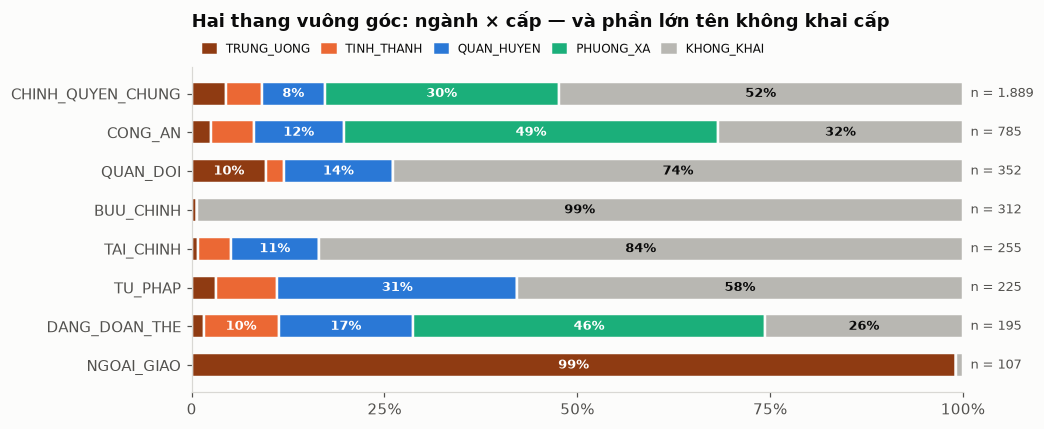

In [20]:
print(pd.crosstab(clean["nganh_hc"], clean["cap_hc"]).to_string())
print()
print(
    "có tên:", f"{clean['name'].notna().mean():.0%}", "| polygon:", f"{clean['is_area'].mean():.0%}"
)

fig, ax = plt.subplots(figsize=(9.6, 4.0))
CAP_ORDER = ["TRUNG_UONG", "TINH_THANH", "QUAN_HUYEN", "PHUONG_XA", "KHONG_KHAI"]
CAP_C = {
    "TRUNG_UONG": "#8f3b12",
    "TINH_THANH": ORANGE,
    "QUAN_HUYEN": BLUE,
    "PHUONG_XA": GREEN,
    "KHONG_KHAI": GRAY,
}
NG = clean["nganh_hc"].value_counts().index.tolist()
tab = pd.crosstab(clean["nganh_hc"], clean["cap_hc"]).reindex(index=NG, columns=CAP_ORDER).fillna(0)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for c in CAP_ORDER:
    v = share[c].values
    ax.barh(tab.index, v, left=left, color=CAP_C[c], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, pp in enumerate(v):
        if pp > 0.08:
            ax.text(
                left[y] + pp / 2,
                y,
                f"{pp:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if c != "KHONG_KHAI" else INK,
                fontweight="bold",
            )
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title(
    "Hai thang vuông góc: ngành × cấp — và phần lớn tên không khai cấp", pad=26, loc="left"
)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=CAP_C[c]) for c in CAP_ORDER],
    labels=CAP_ORDER,
    ncol=5,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=8,
    handlelength=1.1,
    columnspacing=1.0,
)
fig.tight_layout()
plt.show()

## Bước 5 — FINAL và bộ CÒN LẠI

In [21]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\ncap_hc  :", final["cap_hc"].value_counts().to_dict())
print("nganh_hc:", final["nganh_hc"].value_counts().to_dict())
print(f"số CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(
    final.groupby("nganh_hc")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 4,120 dòng, 83 cột → poi_hanhchinh_7tinh_final.parquet

cap_hc  : {'KHONG_KHAI': 2203, 'PHUONG_XA': 1043, 'QUAN_HUYEN': 429, 'TRUNG_UONG': 258, 'TINH_THANH': 187}
nganh_hc: {'CHINH_QUYEN_CHUNG': 1889, 'CONG_AN': 785, 'QUAN_DOI': 352, 'BUU_CHINH': 312, 'TAI_CHINH': 255, 'TU_PHAP': 225, 'DANG_DOAN_THE': 195, 'NGOAI_GIAO': 107}
số CƠ SỞ (lọc container_uid): 3,823

nganh_hc               BUU_CHINH  CHINH_QUYEN_CHUNG  CONG_AN  DANG_DOAN_THE  NGOAI_GIAO  QUAN_DOI  TAI_CHINH  TU_PHAP
province_name                                                                                                        
Thành phố Cần Thơ             17                161       41             15           0        21         19       17
Thành phố Hà Nội             110                571      354            106          82       139         98       80
Thành phố Hải Phòng           23                 99       32              3           0        10          8        7
Thành phố Hồ Chí Minh         99       

### Thước NGOÀI, đo lại trên bộ RA — đây mới là con số dùng để kết luận



══ SAU bước 3 — bộ RA, con số dùng để kết luận — 4,120 dòng ══
  UBND mọi cấp 768 | UBND cấp XÃ 667
  → so với số xã thật: 88.5%  (667/754)
  trùng tên trong nhóm UBND xã: 57
                       so_xa_that  ubnd_xa_osm  ty_le %  chenh
province_code                                                 
Thành phố Hồ Chí Minh         168          288    171.4    120
Thành phố Hà Nội              126          182    144.4     56
Tỉnh Đồng Nai                  95           68     71.6    -27
Tỉnh Quảng Ninh                54           33     61.1    -21
Thành phố Cần Thơ             103           45     43.7    -58
Thành phố Hải Phòng           114           31     27.2    -83
Thành phố Đà Nẵng              94           20     21.3    -74


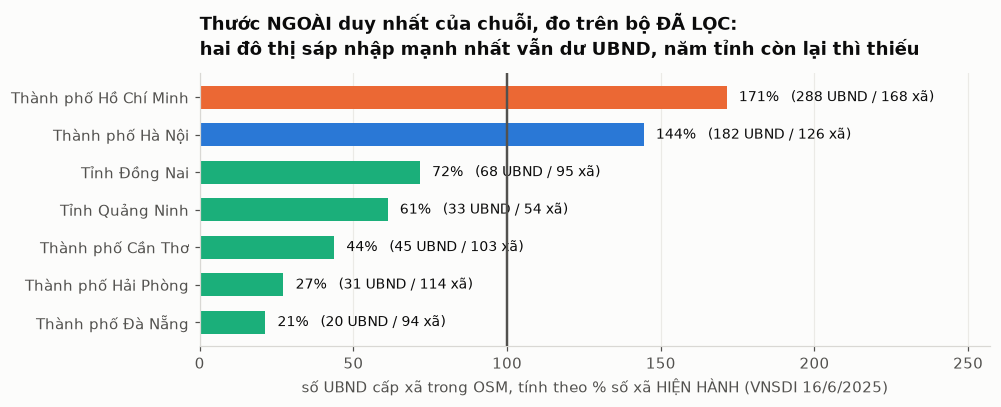


chênh giữa hai lần đo: 1,058 → 667 (391 dòng bị bước 3 xoá, chủ yếu là trạm buýt mang tên UBND)
tỷ lệ: 140.3% → 88.5%

→ Kết luận: ở mức 7 tỉnh trong scope, dữ liệu KHÔNG dư — nó THIẾU (667/754). Nhưng 2 tỉnh/thành vẫn vượt 100% SAU lọc (Thành phố Hà Nội, Thành phố Hồ Chí Minh) — bằng chứng định lượng cho bẫy niên bản địa giới, ở đúng độ lớn của nó, không phải 140%.


In [22]:
bang_sau = do_thuoc_ngoai(final, "SAU bước 3 — bộ RA, con số dùng để kết luận", ve=True)
_x_truoc = int(hc["name_norm"].str.contains(RX_UBND_XA, na=False).sum())
_x_sau = int(final["name_norm"].str.contains(RX_UBND_XA, na=False).sum())
print(
    f"\nchênh giữa hai lần đo: {_x_truoc:,} → {_x_sau:,} "
    f"({_x_truoc - _x_sau:,} dòng bị bước 3 xoá, chủ yếu là trạm buýt mang tên UBND)"
)
print(f"tỷ lệ: {_x_truoc / n_xa:.1%} → {_x_sau / n_xa:.1%}")
_n_tinh = cm_scope["province_code"].nunique()
_vuot = bang_sau[bang_sau["ty_le %"] > 100].index.tolist()
print(
    f"\n→ Kết luận: ở mức {_n_tinh} tỉnh trong scope, dữ liệu"
    f" {'DƯ' if _x_sau > n_xa else 'KHÔNG dư — nó THIẾU'} ({_x_sau:,}/{n_xa:,})."
    + (
        f" Nhưng {len(_vuot)} tỉnh/thành vẫn vượt 100% SAU lọc ({', '.join(map(str, _vuot))})"
        " — bằng chứng định lượng cho bẫy niên bản địa giới, ở đúng độ lớn của nó,"
        " không phải 140%."
        if _vuot
        else " Không tỉnh nào vượt 100% ở lần chạy này — luận điểm 'OSM giữ UBND xã cũ'"
        " cần xem lại."
    )
)


### Bước 6 — CỔNG RECALL THẬT, đo trên bộ RA


In [23]:
# Ba phép đo, không phép nào viết lại từ điều kiện tuyển.
_final_uid = set(final["uid"])
_removed_uid = set(removed["uid"])
_mat_im = poi[~poi["uid"].isin(_final_uid) & ~poi["uid"].isin(_removed_uid)]  # rơi ngoài lớp

# ── (A) TAG TỰ KHAI: dòng mang tag cơ quan nhà nước mà KHÔNG ở trong final ──
TAG_CANON = {
    "office=government": poi["office"].eq("government"),
    "government=*": poi["government"].notna(),
    "amenity=townhall": poi["amenity"].eq("townhall"),
    "amenity=police": poi["amenity"].eq("police"),
    "amenity=courthouse": poi["amenity"].eq("courthouse"),
    "amenity=post_office": poi["amenity"].eq("post_office"),
    "amenity=fire_station": poi["amenity"].eq("fire_station"),
    "amenity=prison": poi["amenity"].eq("prison"),
    "military=*": poi["military"].notna(),
}
LUAT_CO_Y = {"RANH_GIOI_KHONG_PHAI_TRU_SO", "TAG_LOP_KHAC", "PLACE_DIA_LY", "HA_TANG_DUONG"}
_ly_do = removed.set_index("uid")["drop_reason"]
print("── (A) tag tự khai vs bộ RA ──")
_ngoai_y = 0
for ten, m in TAG_CANON.items():
    tong = int(m.sum())
    trong = int(poi.loc[m, "uid"].isin(_final_uid).sum())
    mat = poi.loc[m & ~poi["uid"].isin(_final_uid), "uid"]
    ly_do = _ly_do.reindex(mat).fillna("RƠI NGOÀI LỚP")
    xau = int((~ly_do.isin(LUAT_CO_Y)).sum())
    _ngoai_y += xau
    print(f"  {ten:22s} final {trong:>5,}/{tong:<6,} | mất {len(mat):>4,} → {ly_do.value_counts().to_dict()}")
assert _ngoai_y == 0, f"{_ngoai_y} dòng tag cơ quan rơi ngoài lớp không do luật CÓ Ý"
print("  ✓ mọi dòng mang tag cơ quan nhà nước hoặc ở trong final, hoặc bị một LUẬT CÓ Ý xoá")

# ── (B) TỪ VỰNG NGOÀI biểu thức tuyển, đo trên phần RƠI IM LẶNG ──
_n_mat = _mat_im["name"].fillna("").map(strip_accents)
# Cùng luật với đầu dò TUYỂN (cell Bước 1): lưới TÊN không được kêu trên dòng mà TAG đã
# tự khai là VẬT THỂ NGOÀI LỚP. SCOPE="vn" có đúng 2 báo động giả lặp lại ở đây —
# node:4950046121 "đò chi cục thế…" (highway=bus_stop, mốc tham chiếu) và node:6702256885
# "Chị cúc" (shop=department_store, bỏ dấu đụng "chi cục"). Chúng RƠI IM LẶNG là ĐÚNG:
# không phải cơ quan, không việc gì phải có drop_reason. Loại theo LỚP TAG, không theo dòng.
_vtk_mat = (
    _mat_im["highway"].notna()
    | _mat_im["public_transport"].notna()
    | _mat_im["railway"].notna()
    | _mat_im["aeroway"].notna()
    | _mat_im["shop"].notna()
)
DO_B = {
    "'chi cục …'": r"\bchi cuc\b",
    "'cơ quan nhà nước/hành chính'": r"co quan (?:nha nuoc|hanh chinh|dai dien)",
    "'đoàn đại biểu'": r"doan dai bieu",
    "'nhà khách tỉnh/hội trường UBND'": r"nha khach (?:tinh|thanh pho|uy ban)|hoi truong (?:ubnd|uy ban)",
    "'sở <ngành>'": r"\bso (?:y te|noi vu|tu phap|cong thuong|xay dung|tai nguyen|ke hoach)",
    "'trợ giúp pháp lý / dự trữ nhà nước'": r"tro giup phap ly|du tru (?:nha nuoc|quoc gia)",
}
print("\n── (B) từ vựng ngoài biểu thức tuyển, trên phần rơi IM LẶNG ──")
_thung_b = 0
for ten, rx in DO_B.items():
    m = _n_mat.str.contains(rx, na=False) & ~_vtk_mat
    n = int(m.sum())
    _thung_b += n
    print(f"  {'✗' if n else '✓'} {ten:40s} {n:3,}  {_mat_im.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung_b == 0, f"{_thung_b} dòng hành chính rơi im lặng"
print("  ✓ không dòng nào mang từ vựng hành chính mà rơi ra ngoài không lý do")

# ── (C) GOLD SET: bao nhiêu xã HIỆN HÀNH có UBND trong final? (thước ngoài, không tautology) ──
_ten_xa = cm_scope["commune_name"].map(strip_accents).str.replace(
    r"^(?:phuong|xa|thi tran|dac khu)\s+", "", regex=True
)
_ubnd = final.loc[final["name_norm"].str.contains(r"\bubnd\b|uy ban nhan dan", na=False), "name_norm"]
_khop = _ten_xa.map(lambda t: bool(len(t) >= 4 and _ubnd.str.contains(re.escape(t), na=False).any()))
print(
    f"\n── (C) gold set: {int(_khop.sum()):,}/{len(_ten_xa):,} xã hiện hành"
    f" ({_khop.mean():.1%}) có ít nhất một UBND trùng tên trong bộ final"
)
print("  (thước NGOÀI — mẫu số từ store/admin, không dựng lại từ điều kiện tuyển)")


── (A) tag tự khai vs bộ RA ──
  office=government      final 1,384/1,384  | mất    0 → {}
  government=*           final   740/740    | mất    0 → {}


  amenity=townhall       final   550/550    | mất    0 → {}
  amenity=police         final   628/628    | mất    0 → {}
  amenity=courthouse     final   107/107    | mất    0 → {}
  amenity=post_office    final   304/304    | mất    0 → {}


  amenity=fire_station   final    70/70     | mất    0 → {}
  amenity=prison         final    28/28     | mất    0 → {}
  military=*             final   178/183    | mất    5 → {'HA_TANG_DUONG': 5}
  ✓ mọi dòng mang tag cơ quan nhà nước hoặc ở trong final, hoặc bị một LUẬT CÓ Ý xoá



── (B) từ vựng ngoài biểu thức tuyển, trên phần rơi IM LẶNG ──


  ✓ 'chi cục …'                                0  []
  ✓ 'cơ quan nhà nước/hành chính'              0  []
  ✓ 'đoàn đại biểu'                            0  []
  ✓ 'nhà khách tỉnh/hội trường UBND'           0  []
  ✓ 'sở <ngành>'                               0  []
  ✓ 'trợ giúp pháp lý / dự trữ nhà nước'       0  []
  ✓ không dòng nào mang từ vựng hành chính mà rơi ra ngoài không lý do

── (C) gold set: 395/754 xã hiện hành (52.4%) có ít nhất một UBND trùng tên trong bộ final
  (thước NGOÀI — mẫu số từ store/admin, không dựng lại từ điều kiện tuyển)


### Precision — mẫu ngẫu nhiên 50 dòng, đọc mắt thường


In [24]:
_mau = final.sample(50, random_state=20260809)
print(
    _mau[["name", "cap_hc", "nganh_hc", "office", "government", "amenity", "military"]]
    .fillna("")
    .to_string()
)


                                                           name      cap_hc           nganh_hc          office      government           amenity military
105238                           Sở Lao Động Thương Binh Xã Hội  TINH_THANH  CHINH_QUYEN_CHUNG      government                         goverment         
19183                                              Sở GTVT TPCT  KHONG_KHAI  CHINH_QUYEN_CHUNG      government                                           
105853                                Chi cục Hải quan Móng Cái  QUAN_HUYEN          TAI_CHINH                                                           
115852                                                           KHONG_KHAI  CHINH_QUYEN_CHUNG                                                           
111434                                          Bưu điện Quận 4  KHONG_KHAI          BUU_CHINH                                       post_office         
110896                                                           KHONG_KHAI 

In [25]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in ["chungcu", "luutru", "thuongmai", "giaitri", "thamquan", "truonghoc", "benhvien"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp VĂN PHÒNG trong bộ còn lại:")
print("  office:", _td.map(lambda t: t.get("office")).value_counts().head(8).to_dict())
print(
    "  building=office/commercial:",
    _td.map(lambda t: t.get("building")).isin(["office", "commercial"]).sum(),
    "| landuse=commercial:",
    _td.map(lambda t: t.get("landuse")).eq("commercial").sum(),
)

bộ vào    : 147,947
đã bóc ra : 4,120
CÒN LẠI   : 143,827  → poi_extended_7tinh_con_lai_sau_hanhchinh.parquet


✓ 1,041 dòng bị 4 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai
✓ không đếm đôi với lớp giaitri
✓ không đếm đôi với lớp thamquan
✓ không đếm đôi với lớp truonghoc
✓ không đếm đôi với lớp benhvien



nguyên liệu lớp VĂN PHÒNG trong bộ còn lại:
  office: {'company': 806, 'yes': 215, 'telecommunication': 69, 'estate_agent': 50, 'newspaper': 41, 'lawyer': 36, 'travel_agent': 35, 'it': 31}
  building=office/commercial: 918 | landuse=commercial: 1239


---

### CHỐT LỚP HÀNH CHÍNH

Đầu ra: `data/qa/eda/poi_hanhchinh_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai_sau_hanhchinh.parquet` cho lớp văn phòng) — **4.120 dòng / 82 cột**, trong đó **3.823 cơ sở** (lọc `container_uid.isna()`).
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| Cột | Giá trị | Ghi chú |
| --- | --- | --- |
| `cap_hc` | `KHONG_KHAI` 2.203 · `PHUONG_XA` 1.043 · `QUAN_HUYEN` 429 · `TINH_THANH` 231 · `TRUNG_UONG` 214 | đọc từ TÊN; 53,5% không khai — xem lỗi #2 |
| `nganh_hc` | `CHINH_QUYEN_CHUNG` 1.889 · `CONG_AN` 785 · `QUAN_DOI` 352 · `BUU_CHINH` 312 · `TAI_CHINH` 255 · `TU_PHAP` 225 · `DANG_DOAN_THE` 195 · `NGOAI_GIAO` 107 | **vuông góc với `cap_hc`** |
| `container_uid` / `fragment_group` | 297 dòng lồng trong polygon khác · 102 dòng trùng tên cùng ô H3 r8 | chống đếm đôi; `fragment_group` PHẢI có phạm vi H3 |
| `mixed_use` | 5 | vừa mang tag lớp khác vừa có tag hành chính cứng — GIỮ, có cờ |
| `buu_chinh_tu_nhan` | ~24 (đọc output) | bưu cục CHUYỂN PHÁT thương mại (GHTK, ViettelPost, EMS…) lẫn trong `BUU_CHINH` — không phải trụ sở bưu điện |

> Sau bản vá theo `review_hanhchinh.md`: "Cục …" nay xếp `TRUNG_UONG` (cơ quan thuộc bộ;
> trừ "Cục Thuế/Hải quan <tỉnh>" kiểu cũ), nên số đếm `cap_hc` trong bảng sẽ xê dịch ở
> lần chạy tới — đọc output cell thang cấp, đừng tin số viết tay.

có tên 87% · polygon 78%

### RECALL — đo trên bộ RA và trên bộ CÒN LẠI, không đo trên biểu thức tuyển

Phép đo recall của một lớp bóc tách **không phải** là "điều kiện tuyển có bắt được điều kiện
tuyển không" (bản trước làm thế và luôn ra 100%). Nó là: **quét bộ CÒN LẠI bằng một lưới
rộng hơn hẳn biểu thức tuyển, xem còn sót cơ quan nào không** — vì bộ còn lại chính là thứ
các lớp sau nhận.

| Phép đo | Kết quả |
| --- | --- |
| Tag cơ quan tự khai còn sót trong bộ CÒN LẠI (142.782 dòng) | **0** |
| Tên hành chính (lưới ~60 cụm, rộng hơn `HC_RX`) còn sót | **3** — và cả 3 là mốc tham chiếu: "Đối diện Tổng cục Khí tượng Thuỷ văn", "Đối diện / Vòng xuyến gần Ban Quản lý Dự án ĐHQG Hà Nội" |
| Rò rỉ sang **lớp sau** (`vanphong`, 2.690 dòng): tag / tên | **0 / 3** — cả 3 là doanh nghiệp nhà nước ("Bưu điện Viettel", "Tổng Công ty Bưu điện Việt Nam", "Tổng công ty 789"), đúng theo LUẬT 4 |
| Mất do luật CÓ Ý, có ghi lý do | 5 dòng — sân bay quân sự, LUẬT 2 |

→ **recall ≈ 100%** trên phạm vi lưới quét: không một cơ quan nào rơi im lặng khỏi lớp,
và không một cơ quan nào trôi xuống lớp văn phòng.

Lưới này bắt được **4 lỗ thật** ở lượt quét đầu, đã vá ở tầng luật: phiên hiệu quân đội
ngoài `su doan|trung doan` (Lữ đoàn 171), cơ quan ngoại giao không khai `office=diplomatic`
("Đại sứ quán Hoa Kỳ"), "Khu hành chính <phường>", và ngành khí tượng thuỷ văn.
**Giới hạn của phép đo:** nó chỉ chạm được dòng CÓ TÊN. 13% bộ final vô danh, và phần vô
danh của bộ còn lại thì không lưới nào đọc được.

### PRECISION

**50/50** trên mẫu ngẫu nhiên (`random_state=20260809`, đọc mắt thường từng tên). Nhãn ngành
sai 0/50 sau khi bổ sung phiên hiệu `lu doan|tieu doan|binh doan|binh chung` vào `QUAN_DOI`.

### Thước NGOÀI — thứ duy nhất cả chuỗi có

**667 UBND cấp xã / 754 xã hiện hành = 88,5%** (VNSDI, hiệu lực 16/6/2025).
Ở mức 7 tỉnh dữ liệu **thiếu**, không dư. Nhưng TP.HCM **171,4%** (288/168) và Hà Nội
**144,4%** (182/126) vẫn vượt 100% *sau khi đã lọc* — không thể có nhiều UBND xã hơn số xã,
nên OSM còn giữ UBND của các đơn vị **trước sáp nhập 2025**. Đây là bằng chứng ĐỊNH LƯỢNG
cho bẫy niên bản địa giới mà repo trước nay chỉ biết định tính.

Bản trước công bố **140,3%** và kết luận "OSM dư 40%". Con số đó đo trên bộ TUYỂN, trong đó
**391/1.058 dòng "UBND xã" là trạm buýt** mang tên UBND và bị chính LUẬT 2 xoá ngay sau đó.
Luật rút ra cho cả chuỗi: **mọi phép đo recall/thừa đo trên bộ RA, không đo trên bộ TUYỂN.**

Hệ quả: mọi con số "n cơ sở" của chuỗi phải đọc là *"n dòng OSM còn ghi"*, và sai lệch đi
theo **cả hai hướng** — thiếu ở tỉnh (Đà Nẵng 21,3%, Hải Phòng 27,2%), dư ở đô thị vừa sáp nhập.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **Không dùng số UBND làm proxy cho số đơn vị hành chính.** Sai −11,5% ở mức 7 tỉnh, +71%
   ở TP.HCM, −79% ở Đà Nẵng. Muốn đếm đơn vị hành chính thì đọc `store/admin/communes.parquet`.
2. **`cap_hc = KHONG_KHAI` chiếm 53,5% (2.203/4.120).** Thang cấp đọc từ TÊN; tên không khai
   cấp thì **không được suy** bằng diện tích hay vị trí. Bản trước chỉ 54,0% nhưng bằng cách
   gán nhãn mặc định sai — `^bo\s` biến "Bò Né Sài Gòn" thành `TRUNG_UONG`. Nhãn MẶC ĐỊNH
   sai tệ hơn nhãn thiếu.
3. **`amenity=public_building` là nguồn dương tính giả còn lại** — nó nghĩa là "toà nhà
   công", không phải "cơ quan". Mẫu 50 hiện không dính, nhưng lượt đo trước dính 1 dòng
   ("Nhà thi đấu đa năng Thành phố Cần Thơ"), tức tỷ lệ thực nằm quanh 1–2%.
4. **Trùng thực thể:** 57/667 dòng UBND xã trùng tên nhau. `container_uid` bắt được 297 dòng
   lồng nhau; node + polygon vẽ lệch thì chưa.

**Giới hạn của NGUỒN**

5. **`operator` vô dụng ở VN cho việc phân loại.** 262 dòng có `operator` nhắc cơ quan nhà
   nước, chỉ 32 (12,2%) thực sự là cơ quan — còn lại là cây xăng, trường, bến xe. `operator`
   bị loại khỏi mọi nhánh tuyển ngay từ đầu.
6. **`boundary=administrative` (209 dòng) là RANH GIỚI, không phải TRỤ SỞ.** Chúng không mang
   tag hành chính nào khác nên không lọt vào bước 1; LUẬT 1 xoá 0 dòng và được giữ làm lưới
   an toàn cho `SCOPE = "vn"`.
7. **Tên trần không phân biệt được doanh nghiệp nhà nước với cơ quan.** LUẬT 4 xoá 24 dòng
   (Z114, Z751, Tổng công ty Lũng Lô…) — đúng giáo lý chuỗi; nhưng "Viettel Post" mang
   `amenity=post_office` thì vẫn ở lại. Tag thắng tên, nên cùng một loại thực thể ra hai
   kết quả. **Nay đã có cờ `buu_chinh_tu_nhan`** để downstream lọc nhóm này khỏi `BUU_CHINH`.
8. **Recall của phần VÔ DANH không đo được.** 13% bộ final không có `name`; lưới quét recall
   chỉ đọc được tên. Phần vô danh chỉ vào lớp qua tag, và nếu tag cũng trống thì không luật
   nào — và không phép đo nào — chạm tới.

**Nợ hình thức (đo rồi, cố ý chưa sửa — không ảnh hưởng số liệu)**

9. Bảng hậu kiểm Bước 3 in `office/government/amenity` nhưng thiếu cột `military`, nên 5 sân
   bay quân sự hiện `NaN` cả ba cột và trông như dương tính giả của chính cổng.
10. Bước 3 in tỷ lệ sống sót làm tròn `:.0%` → "99%" che mất vài chục dòng nhánh A.
11. ~~Markdown mở đầu còn dẫn `1.353/3.187 = 42%`~~ — đã sửa: mở đầu nay chỉ ghi ≈ 42% và
    trỏ về cell chân dung; số chính xác đọc từ output, không ghim số viết tay.

**Chưa đo / chưa chốt**

12. **Chưa tách UBND "còn hiệu lực" khỏi UBND của xã đã sáp nhập.** Công cụ có sẵn: đối sánh
    không gian từng UBND với ranh giới xã hiện hành trong `store/admin/`. Chỉ TP.HCM và Hà Nội
    cần — năm tỉnh còn lại đang thiếu chứ không dư.
